In [1]:
!pip install scikit-learn numpy matplotlib pandas


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

mnist = fetch_openml('mnist_784', as_frame=False)
mnist_X = mnist.data.astype('float32')
mnist_y = mnist.target.astype('int64')

In [3]:
# Keep only samples labeled 0 or 7
# mask_07 = (mnist_y == 0) | (mnist_y == 7)
# mnist_X = mnist_X[mask_07]
# mnist_y = mnist_y[mask_07]

# Keep only samples labeled 0, 1, 2, 3, 4, or 5
mask_0_to_5 = (mnist_y >= 0) & (mnist_y <= 5)
mnist_X = mnist_X[mask_0_to_5]
mnist_y = mnist_y[mask_0_to_5]

In [4]:
# Convert grayscale MNIST vectors to binary vectors
# mnist_X = (mnist_X > 123).astype(np.uint8) # uncomment if using ART1

# Convert grayscale MNIST vectors to normalized vectors (range 0..1)
mnist_X = mnist_X.astype(np.float32) / 255.0 # uncomment if using Fuzzy ART

In [5]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    mnist_X,
    mnist_y,
    test_size=0.2,
    random_state=42,
    stratify=mnist_y,
 )

print(f"Train samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Train samples: 33638
Test samples: 8410


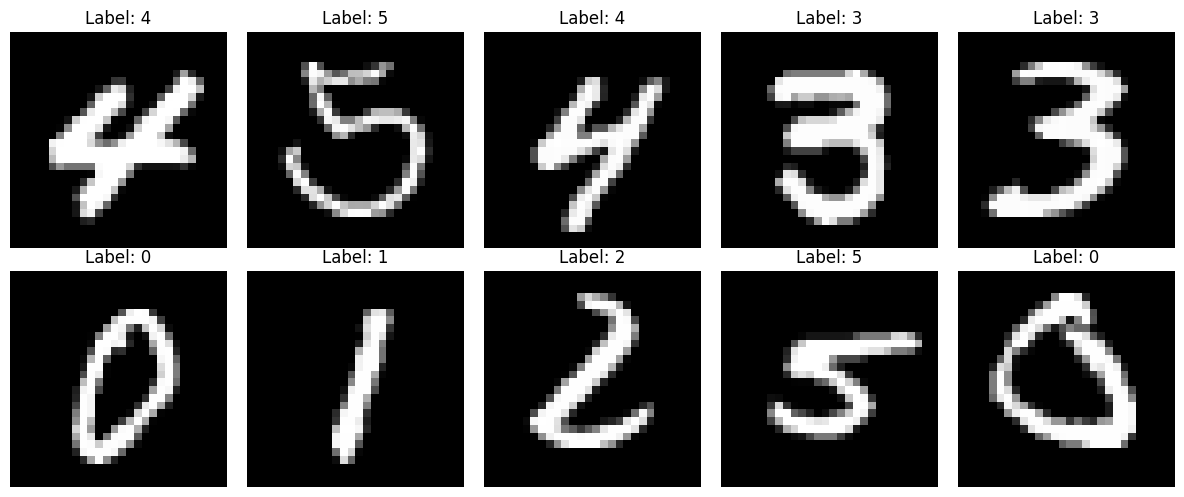

In [6]:
# Visualize some samples
n = 10
idx = np.random.choice(len(mnist_X), n, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, i in zip(axes.ravel(), idx):
    img = mnist_X[i].reshape(28, 28)   # MNIST is flattened (784,) -> (28, 28)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {mnist_y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
class Art1:

    def __init__(self, num_features: int, max_clusters: int = 20, vigilance: float = 0.5):
        if not (0 < vigilance <= 1):
            raise ValueError("Vigilance must be in the range (0, 1].")

        self.vigilance = vigilance # ρ ∈ [0, 1]
        self.num_clusters = 0
        self.max_clusters = max_clusters
        self.num_features = num_features
        # β is a small positive constant (often β < 1)
        self.beta = 0.5
        # Bottom-up weights: b = [b₁ₖ, b₂ₖ, …, bₙₖ] (from F1 to F2 layer)
        self.w_bu = np.full((self.max_clusters, self.num_features), self.beta / (self.beta + self.num_features))
        # Top-down weights (prototype): t = [t₁ₖ, t₂ₖ, …, tₙₖ] (from F2 to F1 layer)
        self.w_td = np.ones((self.max_clusters, self.num_features))

    def _f2_activation(self, X: np.ndarray) -> np.ndarray:
        activations = np.zeros(self.num_clusters)
        # zₖ = ∑ᵢ xᵢ · bᵢₖ
        for j in range(self.num_clusters):
            activations[j] = np.dot(X, self.w_bu[j])
        
        return activations

    def _vigilance_test(self, X: np.ndarray, best_cluster: int) -> bool:
        # |x ∩ tₖ|/|x| = ∑ᵢ(xᵢ · tᵢₖ)/∑ᵢxᵢ
        x_sum = np.sum(X)
        if x_sum == 0:
            return False
        match_ratio = np.dot(X, self.w_td[best_cluster]) / x_sum
        # |x ∩ tₖ|/|x| ≥ ρ
        return match_ratio >= self.vigilance

    def _update_weights(self, X: np.ndarray, cluster_idx: int):
        # tᵢₖ(new) = xᵢ · tᵢₖ(old)
        new_t = X * self.w_td[cluster_idx]
        self.w_td[cluster_idx] = new_t
        # bᵢₖ(new) = β/(β + |tₖ(new)|) · tᵢₖ(new)
        self.w_bu[cluster_idx] = self.beta / (self.beta + np.sum(new_t)) * new_t

    def train(self, X: np.ndarray) -> int:
        X = np.asarray(X, dtype=float)
        if X.shape != (self.num_features,):
            raise ValueError(f"Expected input of shape ({self.num_features},), got {X.shape}.")
        if not np.all((X == 0) | (X == 1)):
            raise ValueError("ART1 requires binary inputs (values must be 0 or 1).")

        inhibited = set()

        while True:
            # 1. Comparison Phase (F1 → F2 propagation)
            if self.num_clusters == 0:
                best_cluster = None
            else:
                # Calculate the activation of each F2 neuron k:
                f2_activations = self._f2_activation(X)
                for j in inhibited:
                    f2_activations[j] = -np.inf
                # Select the F2 neuron K with the highest activation:
                # K = argmax(zₖ)
                best_cluster = int(np.argmax(f2_activations))

            # 2. Matching Phase (Vigilance Test)
            if best_cluster is not None and best_cluster not in inhibited:
                if self._vigilance_test(X, best_cluster):
                    self._update_weights(X, best_cluster)
                    return best_cluster
                else:
                    inhibited.add(best_cluster)

            # 3. Learning Phase
            if self.num_clusters >= self.max_clusters:
                raise RuntimeError(
                    f"Maximum number of clusters ({self.max_clusters}) reached. "
                    "Increase max_clusters or lower vigilance."
                )
            new_idx = self.num_clusters
            self.num_clusters += 1
            self._update_weights(X, new_idx)
            return new_idx

    def predict(self, X: np.ndarray) -> int:
        X = np.asarray(X, dtype=float)
        if self.num_clusters == 0:
            return -1

        activations = self._f2_activation(X)
        sorted_clusters = np.argsort(activations[:self.num_clusters])[::-1]

        for j in sorted_clusters:
            if self._vigilance_test(X, j):
                return int(j)
        return -1

In [8]:
class FuzzyART:

    def __init__(self, num_features: int, max_clusters: int = 20, vigilance: float = 0.5, learning_rate: float = 1.0, alpha: float = 0.001, complement: bool = True):
        if not (0 < vigilance <= 1):
            raise ValueError("Vigilance must be in the range (0, 1].")

        self.vigilance = vigilance # ρ ∈ [0, 1]
        self.num_clusters = 0
        self.max_clusters = max_clusters
        self.num_features = num_features * 2 if complement else num_features
        # β is a small positive constant (often β < 1)
        self.beta = learning_rate
        # α is a small positive constant used in the choice function.
        self.alpha = alpha
        # for each feature xi​, its complement (1−xi)​ is also included in the input vector
        self.complement = complement
        # Bottom-up weights: b = [b₁ₖ, b₂ₖ, …, bₙₖ] (from F1 to F2 layer)
        # self.w_bu = np.full((self.max_clusters, self.num_features), self.beta / (self.beta + self.num_features))
        # Top-down weights (prototype): t = [t₁ₖ, t₂ₖ, …, tₙₖ] (from F2 to F1 layer)
        self.weights = np.ones((self.max_clusters, self.num_features))

    def _complement_code(self, X: np.ndarray) -> np.ndarray:
        return np.concatenate([X, 1 - X])

    def _fuzzy_and(self, X: np.ndarray, W: np.ndarray) -> np.ndarray:
        return np.minimum(X, W)

    def _f2_activation(self, X: np.ndarray) -> np.ndarray:
        activations = np.zeros(self.num_clusters)
        # Tj = ‖x ∧ Wj‖ / α + ‖Wj‖
        for j in range(self.num_clusters):
            activations[j] = np.sum(self._fuzzy_and(X, self.weights[j])) / (self.alpha + np.sum(self.weights[j]))
            # print(f"Cluster {j}: activation={activations[j]:.4f}")
        return activations

    def _vigilance_test(self, X: np.ndarray, best_cluster: int) -> bool:
        # ‖x ∧ Wj‖ / ‖x‖ ≥ ρ
        fuzzy_and_norm = np.sum(self._fuzzy_and(X, self.weights[best_cluster]))
        if fuzzy_and_norm == 0:
            return False
        match_ratio = fuzzy_and_norm / np.sum(X)
        # print(f"Cluster {best_cluster}: match_ratio={match_ratio:.4f}, vigilance={self.vigilance}")
        return match_ratio >= self.vigilance

    def _update_weights(self, X: np.ndarray, cluster_idx: int):
        # wJ (new) = β(x ∧ wJ (old)) + (1 − β)wJ (old)
        new_wj = self.beta * self._fuzzy_and(X, self.weights[cluster_idx]) + (1 - self.beta) * self.weights[cluster_idx]
        self.weights[cluster_idx] = new_wj

    def train(self, X: np.ndarray) -> int:
        X = np.asarray(X, dtype=float)
        X = self._complement_code(X) if self.complement else X

        if X.shape != (self.num_features,):
            raise ValueError(f"Expected input of shape ({self.num_features},), got {X.shape}.")

        inhibited = set()

        while True:
            # 1. Comparison Phase (F1 → F2 propagation)
            if self.num_clusters == 0:
                best_cluster = None
            else:
                # Calculate the activation of each F2 neuron k:
                f2_activations = self._f2_activation(X)
                for j in inhibited:
                    f2_activations[j] = -np.inf
                # Select the F2 neuron K with the highest activation:
                # K = argmax(zₖ)
                best_cluster = int(np.argmax(f2_activations))

            # 2. Matching Phase (Vigilance Test)
            if best_cluster is not None and best_cluster not in inhibited:
                if self._vigilance_test(X, best_cluster):
                    self._update_weights(X, best_cluster)
                    return best_cluster
                else:
                    inhibited.add(best_cluster)

            # 3. Learning Phase
            if self.num_clusters >= self.max_clusters:
                raise RuntimeError(
                    f"Maximum number of clusters ({self.max_clusters}) reached."
                    "Increase max_clusters or lower vigilance."
                )
            new_idx = self.num_clusters
            self.num_clusters += 1
            self.weights[new_idx] = X.copy()
            return new_idx

    def predict(self, X: np.ndarray) -> int:
        X = np.asarray(X, dtype=float)
        X = self._complement_code(X) if self.complement else X
        if self.num_clusters == 0:
            return -1

        activations = self._f2_activation(X)
        sorted_clusters = np.argsort(activations[:self.num_clusters])[::-1]

        for j in sorted_clusters:
            if self._vigilance_test(X, j):
                return int(j)
        return sorted_clusters[0]

    def get_weights(self) -> np.ndarray:
        return self.weights[:self.num_clusters]

In [9]:
from dataclasses import dataclass, field
import math
from pyparsing import Optional

@dataclass
class Kernel:
    """A single Gaussian kernel within one class GMM."""
    mean: np.ndarray          # shape (d,)
    var: np.ndarray           # diagonal variances, shape (d,)
    phi: float                # receptive field (scalar)
    weight: float             # mixture weight ω


class GMM:
    def __init__(self, class_label, d: int, phi_init: float):
        self.label = class_label
        self.d = d
        self.phi_init = phi_init
        self.kernels: list[Kernel] = []
        self.count: int = 0          # number of training samples seen so far

    def _activation(self, x: np.ndarray, k: Kernel) -> float:
        """Compute f(x; μ, Σ, φ) for one kernel (Eq. 3)."""
        safe_var = np.where(k.var > 1e-300, k.var, 1e-300)
        # Σ⁻¹ diagonal = 1/var
        diff = x - k.mean
        mahal = np.sum(diff ** 2 / safe_var)
        phi2 = max(k.phi ** 2, 1e-300)
        norm = 1.0 / math.sqrt(2.0 * math.pi * phi2)
        return norm * math.exp(-mahal / (2.0 * phi2))
 
    def density(self, x: np.ndarray) -> float:
        """p(x) = Σ ω_i · f(x; μ_i, Σ_i, φ_i)"""
        if not self.kernels:
            return 0.0
        return sum(k.weight * self._activation(x, k) for k in self.kernels)
 
    def max_activation(self, x: np.ndarray) -> float:
        """Classification uses max kernel activation per class (Eq. 21)."""
        if not self.kernels:
            return 0.0
        return max(k.weight * self._activation(x, k) for k in self.kernels)
 
    # Posterior P(i|x)  (Eq. 4-6 denominator)
 
    def _posterior(self, x: np.ndarray, k: Kernel) -> float:
        p = self.density(x)
        if p < 1e-300:
            return 0.0
        return k.weight * self._activation(x, k) / p
 
    # EM parameter update (Eqs. 4-6)
 
    def update_parameters(self, x: np.ndarray, n: int):
        """Update μ, σ², ω for all kernels given new sample x."""
        for k in self.kernels:
            p_ix = self._posterior(x, k)
            n_safe = max(n, 1)
            # Eq. 4 – mean
            k.mean = k.mean + p_ix * (x - k.mean) / (n_safe * k.weight + 1e-300)
            # Eq. 5 – variance
            k.var = k.var + p_ix * ((x - k.mean) ** 2 - k.var) / (n_safe * k.weight + 1e-300)
            k.var = np.maximum(k.var, 1e-10)
            # Eq. 6 – weight
            k.weight = k.weight + (p_ix - k.weight) / n_safe
 
        # Re-normalise weights to sum to 1
        total = sum(k.weight for k in self.kernels)
        if total > 1e-300:
            for k in self.kernels:
                k.weight /= total
 
    # Receptive-field update on misclassification (Eq. 7)
 
    def update_receptive_field(self, x: np.ndarray, n: int, alpha: float):
        """Adjust φ of the closest (most-activated) kernel of this class."""
        if not self.kernels:
            return
        acts = [self._activation(x, k) for k in self.kernels]
        r = int(np.argmax(acts))
        k = self.kernels[r]
 
        safe_var = np.where(k.var > 1e-300, k.var, 1e-300)
        diff = x - k.mean
        mahal = float(np.sum(diff ** 2 / safe_var))
 
        p_rx = self._posterior(x, k)
        n_safe = max(n, 1)
        w_safe = max(k.weight, 1e-300)
 
        update = p_rx * (mahal / max(self.d, 1) - k.phi ** 2) / (n_safe * w_safe ** 2)
 
        # Saturated linear transfer: clip to [-alpha, alpha]
        if alpha > 0.0:
            update = np.clip(update, -alpha, alpha)
 
        k.phi = math.sqrt(max(k.phi ** 2 + update, 1e-10))
 
    # Add a kernel (Eqs. 8-10)
 
    def _weighted_mean_var_phi(self):
        """Compute weighted mean variance and phi across all kernels."""
        total_w = sum(k.weight for k in self.kernels)
        if total_w < 1e-300:
            return np.ones(self.d), 1.0
        mean_var = sum(k.weight * k.var for k in self.kernels) / total_w
        mean_phi2 = sum(k.weight * k.phi ** 2 for k in self.kernels) / total_w
        return mean_var, math.sqrt(max(mean_phi2, 1e-10))
 
    def add_kernel(self, x: np.ndarray, n: int, K_total: int):
        """
        Add a new kernel centred at x.
        Initial variance / phi borrowed from the current mixture (Eq. 8).
        Weight set to 1/n and existing weights rescaled (Eqs. 9-10).
        """
        if not self.kernels:
            # First kernel ever in this GMM
            new_k = Kernel(
                mean=x.copy(),
                var=np.ones(self.d),
                phi=math.sqrt(self.phi_init),
                weight=1.0,
            )
        else:
            mean_var, mean_phi = self._weighted_mean_var_phi()
            n_safe = max(n, 1)
            new_weight = 1.0 / n_safe
            # Re-scale existing weights (Eq. 10)
            scale = (n_safe - 1) / n_safe
            for k in self.kernels:
                k.weight *= scale
            new_k = Kernel(
                mean=x.copy(),
                var=mean_var.copy(),
                phi=mean_phi,
                weight=new_weight,
            )
        self.kernels.append(new_k)
        # Ensure weights sum to 1
        self._renorm_weights()
 
    def _renorm_weights(self):
        total = sum(k.weight for k in self.kernels)
        if total > 1e-300:
            for k in self.kernels:
                k.weight /= total
 
    # Kernel merging (Eqs. 11-18)
 
    @staticmethod
    def _ellipsoid_volume(var: np.ndarray, d: int) -> float:
        """Volume of a d-dimensional ellipsoid (Eq. 13)."""
        # V = (2 * prod(r_j) * π^(d/2)) / (d * Γ(d/2))
        radii = np.sqrt(np.maximum(var, 1e-300))
        prod_r = float(np.prod(radii))
        gamma_d2 = math.gamma(d / 2.0)
        if gamma_d2 < 1e-300 or d == 0:
            return 1e-300
        volume = 2.0 * prod_r * (math.pi ** (d / 2.0)) / (d * gamma_d2)
        return max(volume, 1e-300)
 
    def _proximity_test(self, p: Kernel, q: Kernel, fac: float, t: float) -> bool:
        """Eq. 11 – check if kernels p and q are close."""
        diff = np.abs(p.mean - q.mean)
        total_diff = float(np.sum(diff))
        if total_diff < 1e-300:
            return True
        spread = fac * (np.sqrt(p.var) + np.sqrt(q.var))
        weighted_spread = float(np.sum(diff * spread)) / total_diff
        dist = float(np.linalg.norm(p.mean - q.mean))
        threshold = weighted_spread + math.sqrt(self.d) * t
        return dist <= threshold
 
    def _homogeneity_test(self, p: Kernel, q: Kernel, d: int) -> bool:
        """Eq. 12 – check if merged kernel is homogeneous."""
        total_w = p.weight + q.weight
        if total_w < 1e-300:
            return False
        # Merged kernel parameters (Eqs. 15-16)
        mean_t = (p.weight * p.mean + q.weight * q.mean) / total_w
        var_t = (
            p.weight * p.var / total_w + (p.mean - mean_t) ** 2
            + (q.mean - mean_t) ** 2
            + q.weight * q.var / total_w
        )
        Vp = self._ellipsoid_volume(p.var, d)
        Vq = self._ellipsoid_volume(q.var, d)
        Vt = self._ellipsoid_volume(var_t, d)
        return Vt <= d * (Vp + Vq)
 
    def _merge_kernels(self, p: Kernel, q: Kernel) -> Kernel:
        """Produce merged kernel t from p and q (Eqs. 15-18)."""
        total_w = p.weight + q.weight
        mean_t = (p.weight * p.mean + q.weight * q.mean) / total_w
        var_t = (
            p.weight * p.var / total_w
            + (p.mean - mean_t) ** 2
            + (q.mean - mean_t) ** 2
            + q.weight * q.var / total_w
        )
        phi2_t = (p.weight * p.phi ** 2 + q.weight * q.phi ** 2) / total_w
        return Kernel(
            mean=mean_t,
            var=np.maximum(var_t, 1e-10),
            phi=math.sqrt(max(phi2_t, 1e-10)),
            weight=total_w,
        )
 
    def try_merge(self, x: np.ndarray, fac: float, t: float):
        """
        Check the two most-active kernels for this class and merge if eligible.
        """
        if len(self.kernels) < 2:
            return
        acts = [self._activation(x, k) for k in self.kernels]
        top2 = np.argsort(acts)[-2:]  # indices of two most active
        pi, qi = int(top2[1]), int(top2[0])
        p, q = self.kernels[pi], self.kernels[qi]
 
        if self._proximity_test(p, q, fac, t) and self._homogeneity_test(p, q, self.d):
            merged = self._merge_kernels(p, q)
            # Remove p and q, add merged
            keep = [i for i in range(len(self.kernels)) if i not in (pi, qi)]
            self.kernels = [self.kernels[i] for i in keep]
            self.kernels.append(merged)
            self._renorm_weights()
 
    # Kernel pruning
 
    def prune_kernels(self, n: int, s: float):
        """Remove kernels whose weight < 1/(n + s) (Section 2.1)."""
        threshold = 1.0 / (n + s)
        self.kernels = [k for k in self.kernels if k.weight >= threshold]
        if self.kernels:
            self._renorm_weights()


class ePNN:
    def __init__(
        self,
        n_max: int = 100,
        phi_init: float = 0.25,
        t: float = 0.0,
        alpha: float = 0.001,
        fac: float = 2.0,
        s: float = 1.0,
        update_variance: bool = True,
    ):
        self.n_max = n_max
        self.phi_init = phi_init
        self.t = t
        self.alpha = alpha
        self.fac = fac
        self.s = s
        self.update_variance = update_variance
 
        self.gmms: dict[any, GMM] = {}   # class_label → ClassGMM
        self.d: Optional[int] = None
        self._total_kernels: int = 0           # K_T across all classes

    @property
    def total_kernels(self) -> int:
        return sum(len(g.kernels) for g in self.gmms.values())

    def train(self, X: np.ndarray, y):
        X = np.asarray(X, dtype=float)

        # Initialise dimensionality on first sample
        if self.d is None:
            self.d = X.shape[0]
 
        # --- New class: add GMM and first kernel ---
        if y not in self.gmms:
            gmm = GMM(y, self.d, self.phi_init)
            self.gmms[y] = gmm
            K_total = self.total_kernels
            gmm.add_kernel(X, n=1, K_total=K_total)
            gmm.count = 1
            return
 
        gmm = self.gmms[y]
        gmm.count += 1
        n = min(gmm.count, self.n_max)
 
        # Pass sample through the network
        y_pred = self.predict(X)
 
        # Update EM parameters for correct class
        gmm.update_parameters(X, n)
 
        # Misclassification branch
        if y_pred != y:
            gmm.update_receptive_field(X, n, self.alpha)
            K_total = self.total_kernels
            gmm.add_kernel(X, n=n, K_total=K_total)
 
        # Merging step
        gmm.try_merge(X, fac=self.fac, t=self.t)
 
        # Pruning step
        gmm.prune_kernels(n, self.s)

    def predict(self, X: np.ndarray):
        if not self.gmms:
            return None
        best_label = None
        best_act = -1.0
        for label, gmm in self.gmms.items():
            act = gmm.max_activation(X)
            if act > best_act:
                best_act = act
                best_label = label
        return best_label



In [10]:
# Divide training data into two halves for incremental learning
X_train_1st_half = X_train[:len(X_train) // 2]
X_train_2nd_half = X_train[len(X_train) // 2:]

y_train_1st_half = y_train[:len(y_train) // 2]
y_train_2nd_half = y_train[len(y_train) // 2:]

In [16]:
# Train ART1 with binary MNIST training split
# net = Art1(
#     num_features=X_train.shape[1],
#     max_clusters=100000,
#     vigilance=0.3,
#  )

net = FuzzyART(
    num_features=X_train_1st_half.shape[1],
    max_clusters=100000,
    vigilance=0.8,
    learning_rate=0.5,
    alpha=0.01,
    complement=True,
)

cluster_assignments = np.full(len(X_train_1st_half), -1, dtype=np.int32)
for i, x in enumerate(X_train_1st_half):
    try:
        cluster_assignments[i] = net.train(x)
    except RuntimeError:
        cluster_assignments = cluster_assignments[:i]
        print(f"Stopped at sample {i}")
        break

print(f"Active clusters: {net.num_clusters}")
print(f"Trained samples: {len(cluster_assignments)}")

# with open("weights.txt", "w") as f:
#     for idx in cluster_assignments:
#         f.write(f"{idx}\n")

# with open("cluster_weights.txt", "w") as f:
#     for weight in net.get_weights():
#         f.write(f"{', '.join(map(str, weight))}\n")

Active clusters: 15619
Trained samples: 16819


Total clusters found: 15619


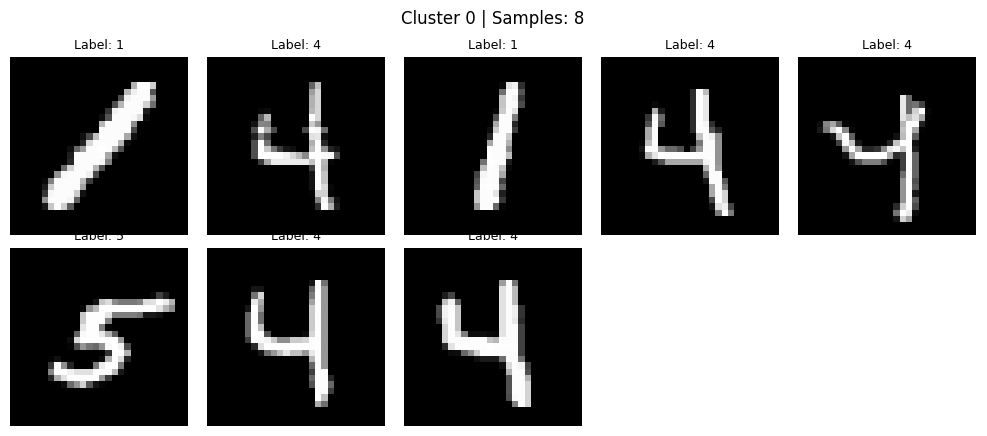

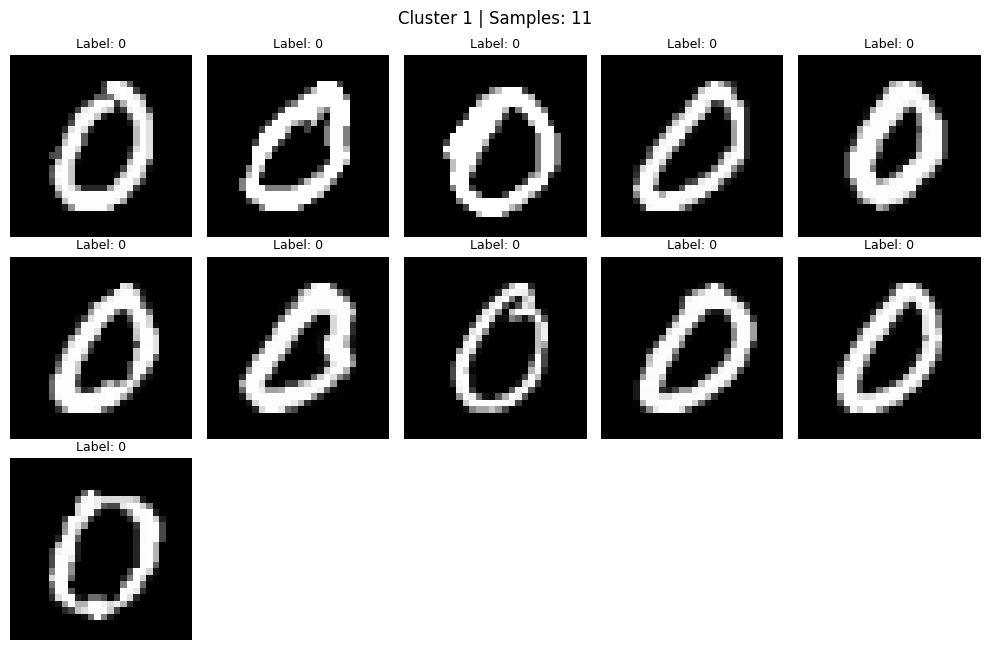

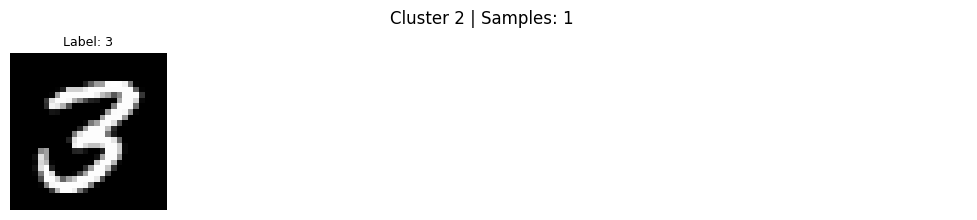

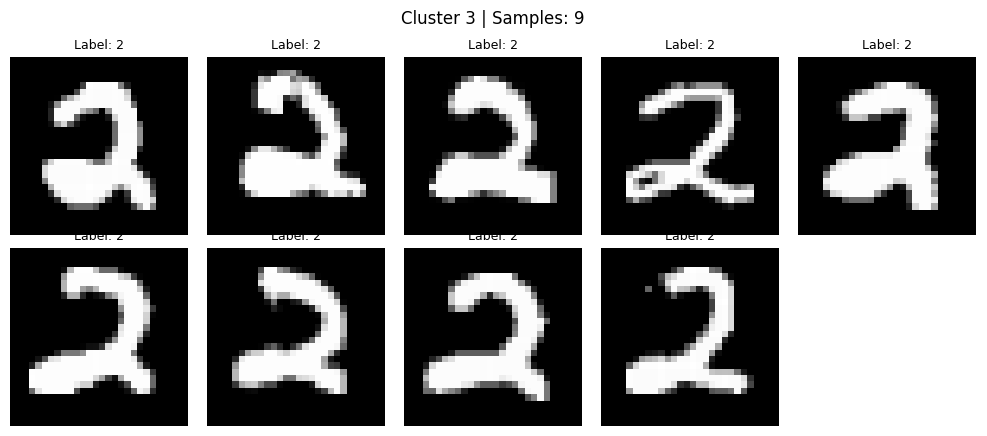

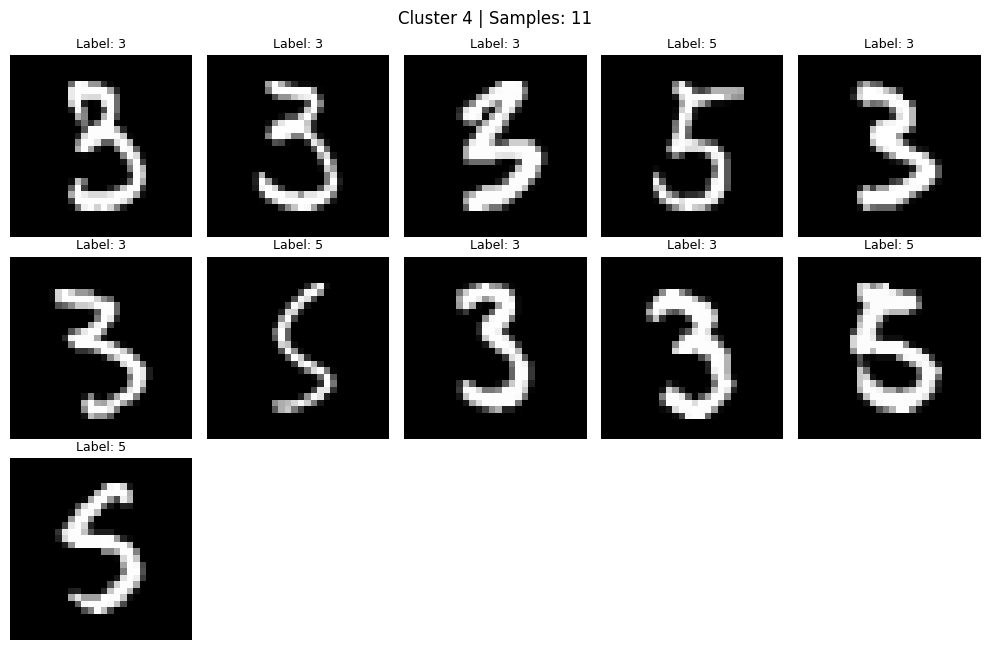

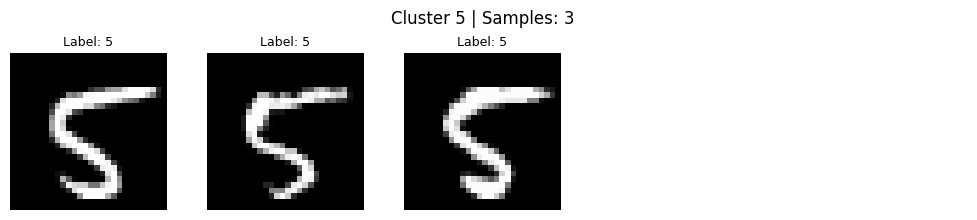

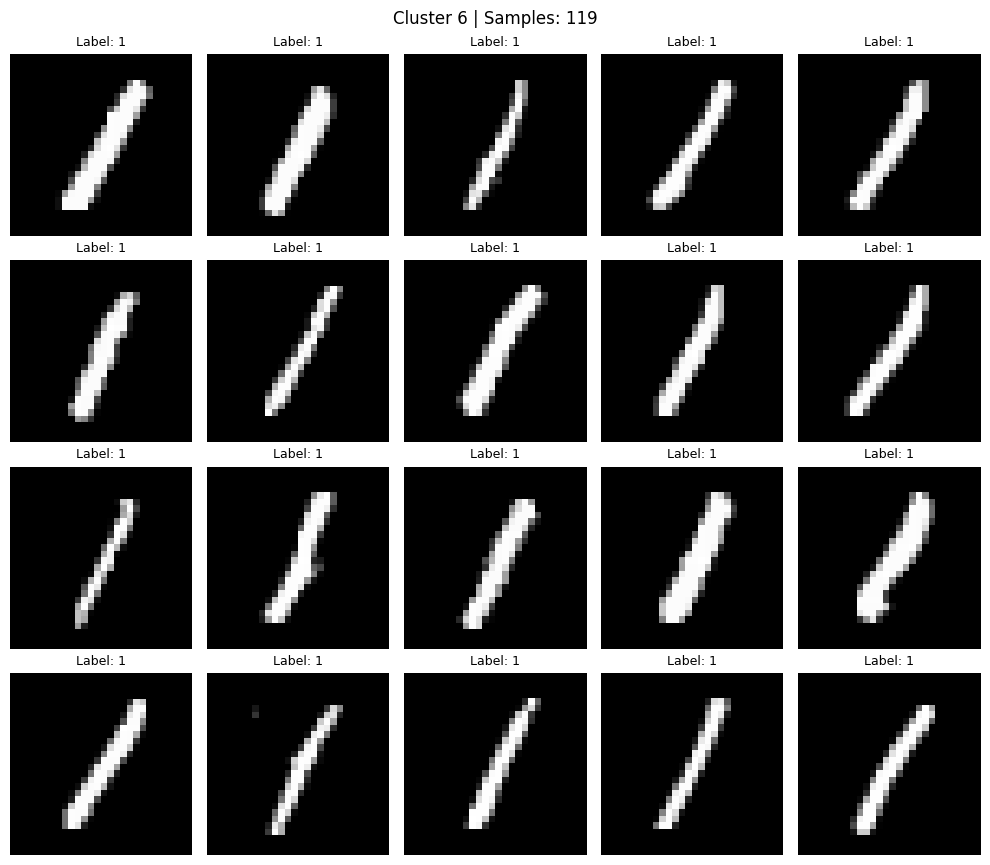

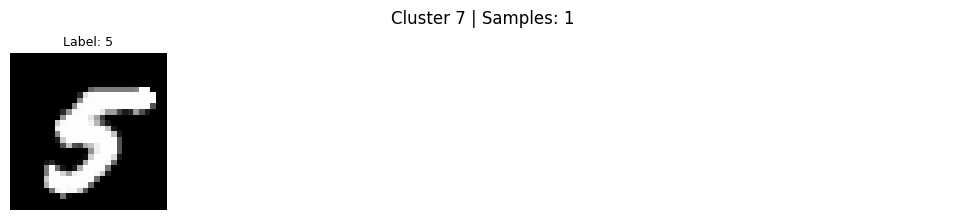

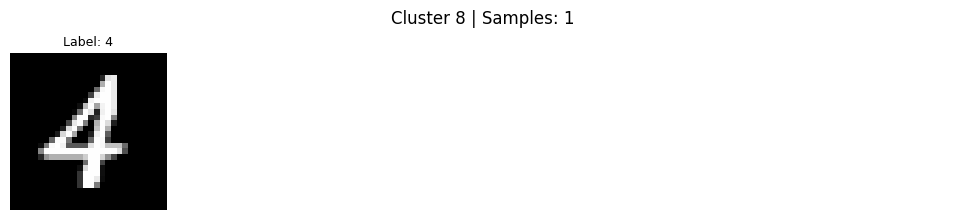

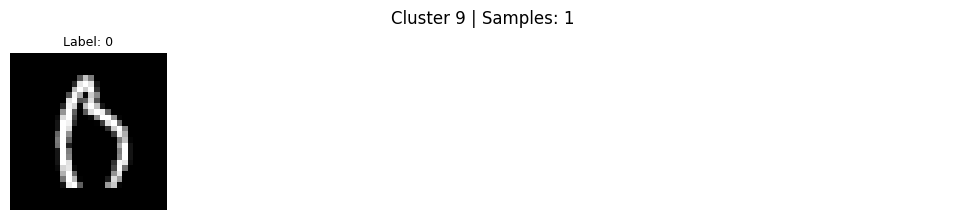

In [17]:
# Show image samples for each cluster
trained_n = len(cluster_assignments)
X_trained = X_train_1st_half[:trained_n]
y_trained = y_train_1st_half[:trained_n]

samples_per_cluster = 20
cluster_ids = np.unique(cluster_assignments)

print(f"Total clusters found: {len(cluster_ids)}")

for cluster_id in cluster_ids[:10]:
    idx = np.where(cluster_assignments == cluster_id)[0]
    if len(idx) == 0:
        continue

    # Pick up to N samples from this cluster (randomized for variety)
    n_show = min(samples_per_cluster, len(idx))
    show_idx = np.random.choice(idx, size=n_show, replace=False)

    cols = 5
    rows = int(np.ceil(n_show / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.2))
    axes = np.array(axes).reshape(-1)

    for ax, sample_i in zip(axes, show_idx):
        ax.imshow(X_trained[sample_i].reshape(28, 28), cmap="gray")
        ax.set_title(f"Label: {y_trained[sample_i]}", fontsize=9)
        ax.axis("off")

    for ax in axes[n_show:]:
        ax.axis("off")

    fig.suptitle(f"Cluster {cluster_id} | Samples: {len(idx)}", fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
from collections import Counter

y_trained = y_train_1st_half[:trained_n]

cluster_label_map = {}

for cid in cluster_ids:
    idx = np.where(cluster_assignments == cid)[0]
    label_counts = Counter(y_trained[idx])
    dominant = label_counts.most_common(1)[0]
    cluster_label_map[cid] = dominant[0]


Mismatch at sample 42: expected 1, predicted 4


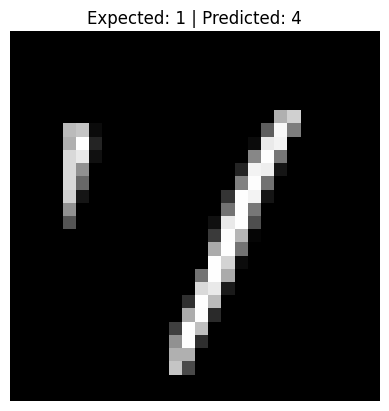

Mismatch at sample 51: expected 2, predicted 0


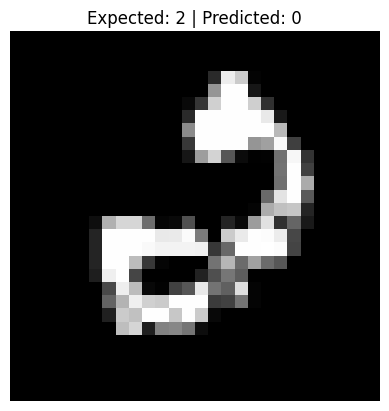

Mismatch at sample 70: expected 5, predicted 4


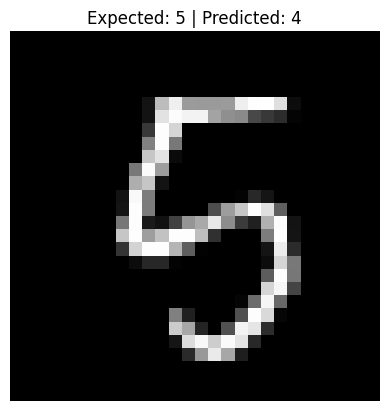

Mismatch at sample 98: expected 3, predicted 2


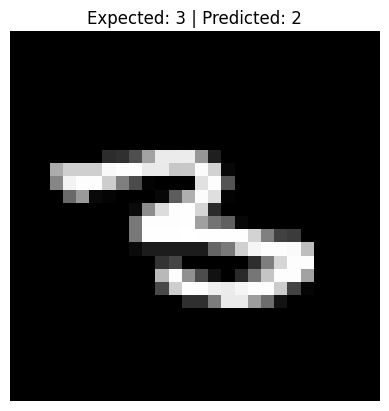

Mismatch at sample 180: expected 2, predicted 4


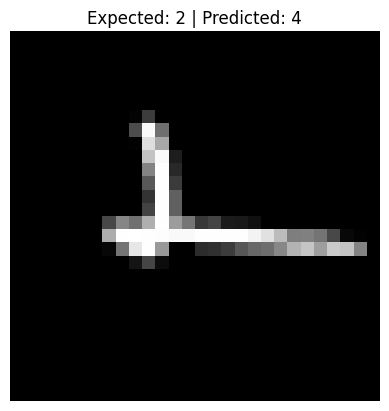

Mismatch at sample 181: expected 5, predicted 3


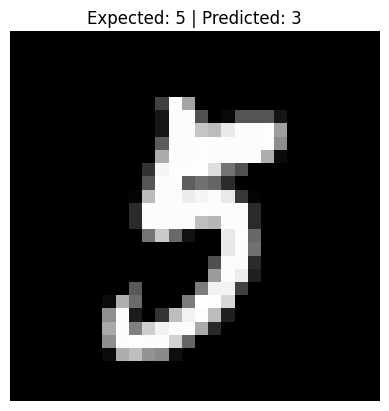

Mismatch at sample 238: expected 4, predicted 2


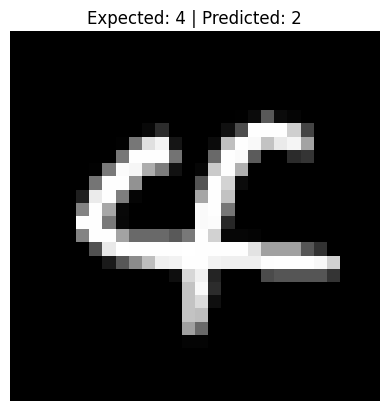

Mismatch at sample 334: expected 4, predicted 0


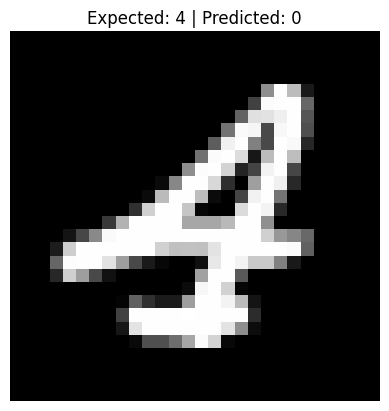

Mismatch at sample 384: expected 5, predicted 3


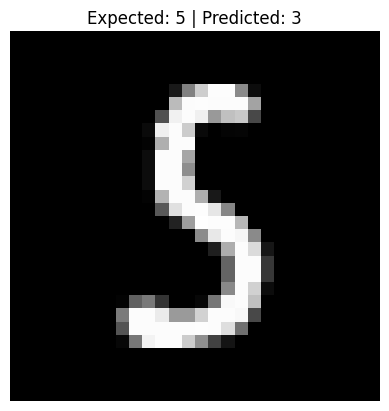

Mismatch at sample 391: expected 2, predicted 1


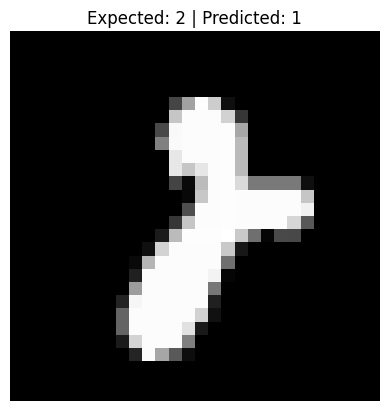

Correct predictions: 8209 out of 8410
Accuracy: 97.61%


In [19]:
def predict_digit(net, cluster_label_map, X):
    cluster_id = net.predict(X)
    if cluster_id == -1:
        return None  # no matching cluster found
    return cluster_label_map[cluster_id]


def display_image_and_prediction(image, expected, predicted):
    plt.imshow(image.reshape(28, 28), cmap="gray")
    plt.title(f"Expected: {expected} | Predicted: {predicted}")
    plt.axis("off")
    plt.show()


accuracy_count = 0
number_to_test = min(10000, len(X_test))
mismatch_count = 0

for i, X in enumerate(X_test[:number_to_test]):
    predicted_digit = predict_digit(net, cluster_label_map, X)
    actual_digit = y_test[i]

    if predicted_digit == actual_digit:
        accuracy_count += 1

    if predicted_digit != actual_digit:
        if mismatch_count >= 10:
            continue
        mismatch_count += 1
        print(f"Mismatch at sample {i}: expected {actual_digit}, predicted {predicted_digit}")
        display_image_and_prediction(X, actual_digit, predicted_digit)

print(f"Correct predictions: {accuracy_count} out of {number_to_test}")
print(f"Accuracy: {accuracy_count / number_to_test * 100:.2f}%")

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# PCA + StandardScaler (epnn-test pipeline)
n_components = 40
pca = PCA(n_components=n_components, random_state=42)
X_train_pca_1st_half = pca.fit_transform(X_train_1st_half)
X_train_pca_2nd_half = pca.fit_transform(X_train_2nd_half)
X_test_pca = pca.transform(X_test)
explained = pca.explained_variance_ratio_.sum() * 100.0
# print(f"PCA explained variance: {explained:.1f}%")

scaler = StandardScaler()
X_train_epnn_1st_half = scaler.fit_transform(X_train_pca_1st_half)
X_train_epnn_2nd_half = scaler.fit_transform(X_train_pca_2nd_half)
X_test_epnn = scaler.transform(X_test_pca)


In [13]:
net_epnn = ePNN(
    n_max=500,
    phi_init=0.30,
    t=0.0,
    alpha=0.005,
    fac=1.2,
    s=0.5,
)

# Train ePNN on the training set
train_limit = len(X_train_epnn_1st_half)
for i in range(train_limit):
    net_epnn.train(X_train_epnn_1st_half[i], int(y_train_1st_half[i]))

train_correct = 0
train_total = len(X_train_epnn_1st_half)
for i in range(train_total):
    pred = net_epnn.predict(X_train_epnn_1st_half[i])
    if pred == int(y_train_1st_half[i]):
        train_correct += 1
train_accuracy = train_correct / train_total if train_total else 0.0
print(f"ePNN train accuracy: {train_accuracy * 100:.2f}% ({train_correct}/{train_total})")

ePNN train accuracy: 90.59% (15237/16819)


In [28]:
import itertools

configs = [
    # dict(n_max=1000, phi_init=0.25, t=0.0, alpha=0.01,  fac=2.5, s=2.0),
    # dict(n_max=1000, phi_init=0.30, t=0.0, alpha=0.005, fac=1.2, s=0.5),
    # dict(n_max=1000, phi_init=0.35, t=0.0, alpha=0.01, fac=2, s=1),
    # dict(n_max=1000, phi_init=0.30, t=0.0, alpha=0.01, fac=1.4, s=1.5),
    dict(n_max=500, phi_init=0.30, t=0.0, alpha=0.005, fac=1.2, s=0.5),
    # dict(n_max=750, phi_init=0.30, t=0.0, alpha=0.005, fac=1.2, s=0.5),
    # dict(n_max=500, phi_init=0.30, t=0.0, alpha=0.005, fac=2.5, s=0.5),
    # dict(n_max=500, phi_init=0.30, t=0.0, alpha=0.005, fac=2.5, s=1.5),
    # dict(n_max=500, phi_init=0.30, t=0.0, alpha=0.005, fac=2.5, s=2.0),
    # dict(n_max=750, phi_init=0.30, t=0.0, alpha=0.005, fac=2.5, s=2.0),
    # dict(n_max=500, phi_init=0.20, t=0.0, alpha=0.01, fac=2.0, s=0.5),
    # dict(n_max=500, phi_init=0.25, t=0.0, alpha=0.005, fac=1.5, s=2.0),
    # dict(n_max=500, phi_init=0.30, t=0.0, alpha=0.005, fac=1.2, s=1.5),
    # dict(n_max=750, phi_init=0.30, t=0.0, alpha=0.01, fac=2.5, s=2.0),
]

total = len(X_test_epnn)
results = []
for cfg in configs:
    net = ePNN(**cfg)
    for i in range(train_limit):
        net.train(X_train_epnn_1st_half[i], int(y_train_1st_half[i]))

    train_correct = sum(
        net.predict(X_train_epnn_1st_half[i]) == int(y_train_1st_half[i])
        for i in range(train_total)
    )
    test_correct = sum(
        net.predict(X_test_epnn[i]) == y_test[i]
        for i in range(total)
    )
    results.append({
        **cfg,
        "train_acc": train_correct / train_total,
        "test_acc": test_correct / total,
        "total_kernels": net.total_kernels,
    })

for r in results:
    print(r)

{'n_max': 500, 'phi_init': 0.3, 't': 0.0, 'alpha': 0.005, 'fac': 1.2, 's': 0.5, 'train_acc': 0.9059397110410845, 'test_acc': np.float64(0.8360285374554103), 'total_kernels': 10}


In [14]:
# Test ePNN on the test set
correct = 0
total = len(X_test_epnn)
for i in range(total):
    pred = net_epnn.predict(X_test_epnn[i])
    if pred == y_test[i]:
        correct += 1

accuracy = correct / total if total else 0.0
print(f"ePNN test accuracy: {accuracy * 100:.2f}% ({correct}/{total})")

ePNN test accuracy: 83.60% (7031/8410)


In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

DIGIT_LABELS = [0, 1, 2, 3, 4, 5]  # dataset usa apenas dígitos 0-5


def compute_metrics(y_true, y_pred, model_name, average="macro"):
    """
    Calcula acurácia, precisão, recall e f1-score agregados para um modelo.
    average='macro' trata todas as classes igualmente.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=average, zero_division=0)
    rec = recall_score(y_true, y_pred, average=average, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=average, zero_division=0)

    return {
        "Modelo": model_name,
        "Acurácia": acc,
        "Precisão": prec,
        "Recall": rec,
        "F1-score": f1,
    }


def compute_metrics_per_digit(y_true, y_pred, model_name, labels=DIGIT_LABELS):
    """
    Calcula precisão, recall e f1-score por dígito (classe individual),
    usando classification_report do sklearn com output_dict=True.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0,
    )

    rows = []
    for digit in labels:
        digit_key = str(digit)
        if digit_key in report:
            rows.append({
                "Modelo": model_name,
                "Dígito": digit,
                "Precisão": report[digit_key]["precision"],
                "Recall": report[digit_key]["recall"],
                "F1-score": report[digit_key]["f1-score"],
                "Suporte (n amostras)": int(report[digit_key]["support"]),
            })
    return rows


# Coletar predições da ePNN
epnn_y_true = []
epnn_y_pred = []
for i in range(len(X_test_epnn)):
    pred = net_epnn.predict(X_test_epnn[i])
    epnn_y_true.append(y_test[i])
    epnn_y_pred.append(pred)

# None (sem GMM aplicável) -> rótulo sentinela, conta como erro
epnn_y_pred_clean = [p if p is not None else -999 for p in epnn_y_pred]

epnn_metrics = compute_metrics(epnn_y_true, epnn_y_pred_clean, "ePNN")
epnn_metrics_per_digit = compute_metrics_per_digit(epnn_y_true, epnn_y_pred_clean, "ePNN")


# Coletar predições da FuzzyART
fuzzyart_y_true = []
fuzzyart_y_pred = []
for i, X in enumerate(X_test[:number_to_test]):
    predicted_digit = predict_digit(net, cluster_label_map, X)
    fuzzyart_y_true.append(y_test[i])
    fuzzyart_y_pred.append(predicted_digit)

# None (cluster_id == -1) -> rótulo sentinela, conta como erro
fuzzyart_y_pred_clean = [p if p is not None else -999 for p in fuzzyart_y_pred]

fuzzyart_metrics = compute_metrics(fuzzyart_y_true, fuzzyart_y_pred_clean, "FuzzyART")
fuzzyart_metrics_per_digit = compute_metrics_per_digit(fuzzyart_y_true, fuzzyart_y_pred_clean, "FuzzyART")


# Tabela comparativa agregada (ePNN vs FuzzyART)
df_comparison = pd.DataFrame([epnn_metrics, fuzzyart_metrics])

df_comparison_display = df_comparison.copy()
for col in ["Acurácia", "Precisão", "Recall", "F1-score"]:
    df_comparison_display[col] = (df_comparison_display[col] * 100).round(2).astype(str) + "%"

print("=== Comparação agregada (macro-average) ===")
print(df_comparison_display.to_string(index=False))


# Tabela de métricas por dígito (0-5), ambos os modelos
df_per_digit = pd.DataFrame(epnn_metrics_per_digit + fuzzyart_metrics_per_digit)

df_per_digit_display = df_per_digit.copy()
for col in ["Precisão", "Recall", "F1-score"]:
    df_per_digit_display[col] = (df_per_digit_display[col] * 100).round(2).astype(str) + "%"

print("\n=== Métricas por dígito (0-5) ===")
print(df_per_digit_display.to_string(index=False))

=== Comparação agregada (macro-average) ===
  Modelo Acurácia Precisão Recall F1-score
    ePNN    83.6%   84.67% 83.53%   83.76%
FuzzyART   97.61%   97.63% 97.57%   97.59%

=== Métricas por dígito (0-5) ===
  Modelo  Dígito Precisão Recall F1-score  Suporte (n amostras)
    ePNN       0   92.15% 90.08%    91.1%                  1381
    ePNN       1   99.78% 84.63%   91.58%                  1575
    ePNN       2   81.71% 86.91%   84.23%                  1398
    ePNN       3   71.43% 78.08%   74.61%                  1428
    ePNN       4   97.59% 83.08%   89.75%                  1365
    ePNN       5   65.39% 78.38%    71.3%                  1263
FuzzyART       0   98.21% 99.42%   98.81%                  1381
FuzzyART       1   96.67% 99.56%   98.09%                  1575
FuzzyART       2   98.45% 95.49%   96.95%                  1398
FuzzyART       3   97.38% 96.15%   96.76%                  1428
FuzzyART       4   98.53% 98.02%   98.27%                  1365
FuzzyART       5   96.52

/tmp/ipykernel_68164/245027602.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", max_kernels)
/tmp/ipykernel_68164/245027602.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


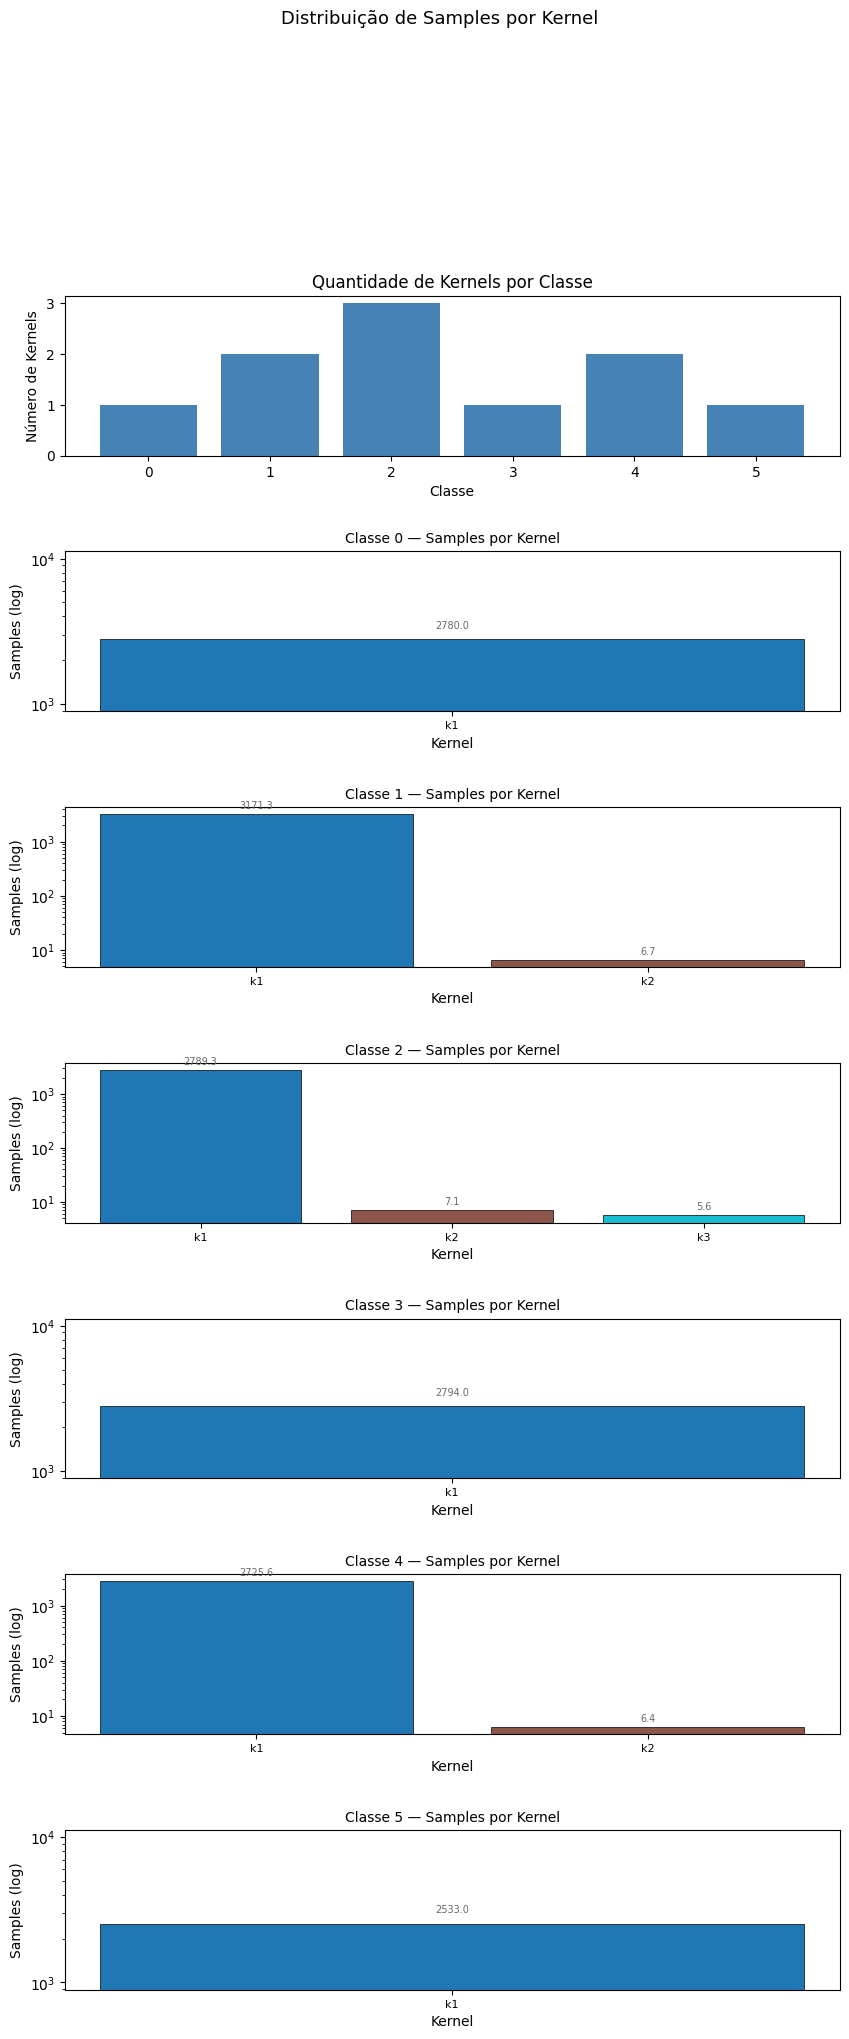

In [22]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

classes = sorted(net_epnn.gmms.keys())

# =========================================================
# Plot 1 — Quantidade de kernels por classe
# =========================================================
kernels_per_class = [len(net_epnn.gmms[c].kernels) for c in classes]

# =========================================================
# Dados — samples estimados por kernel, por classe
# =========================================================
samples_by_class = []
for c in classes:
    gmm = net_epnn.gmms[c]
    samples_by_class.append([k.weight * gmm.count for k in gmm.kernels])

max_kernels = max(len(s) for s in samples_by_class)
cmap = cm.get_cmap("tab10", max_kernels)
kernel_colors = [cmap(i) for i in range(max_kernels)]

# =========================================================
# Layout: 1 linha para kernels/classe + 1 linha por classe
# =========================================================
n_classes = len(classes)
n_rows = 1 + n_classes  # primeira linha = visão geral, demais = uma por classe

fig, axes = plt.subplots(
    n_rows, 1,
    figsize=(10, 4 + 3 * n_classes),
    gridspec_kw={"hspace": 0.6},
)

# --- Gráfico 0: kernels por classe ---
axes[0].bar([str(c) for c in classes], kernels_per_class, color="steelblue")
axes[0].set_title("Quantidade de Kernels por Classe")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Número de Kernels")

# --- Um gráfico por classe: samples por kernel (escala log) ---
for row_idx, (c, samples) in enumerate(zip(classes, samples_by_class), start=1):
    ax = axes[row_idx]
    n_kernels = len(samples)
    x = np.arange(n_kernels)
    colors = [kernel_colors[i] for i in range(n_kernels)]

    bars = ax.bar(x, samples, color=colors, edgecolor="black", linewidth=0.5)

    ax.set_yscale("log")
    ax.set_title(f"Classe {c} — Samples por Kernel", fontsize=10)
    ax.set_xlabel("Kernel")
    ax.set_ylabel("Samples (log)")
    ax.set_xticks(x)
    ax.set_xticklabels([f"k{i+1}" for i in x], fontsize=8)

    # Valor numérico no topo de cada barra
    for bar, val in zip(bars, samples):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val * 1.15,
            f"{val:.1f}",
            ha="center",
            va="bottom",
            fontsize=7,
            color="dimgray",
        )

plt.suptitle("Distribuição de Samples por Kernel", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

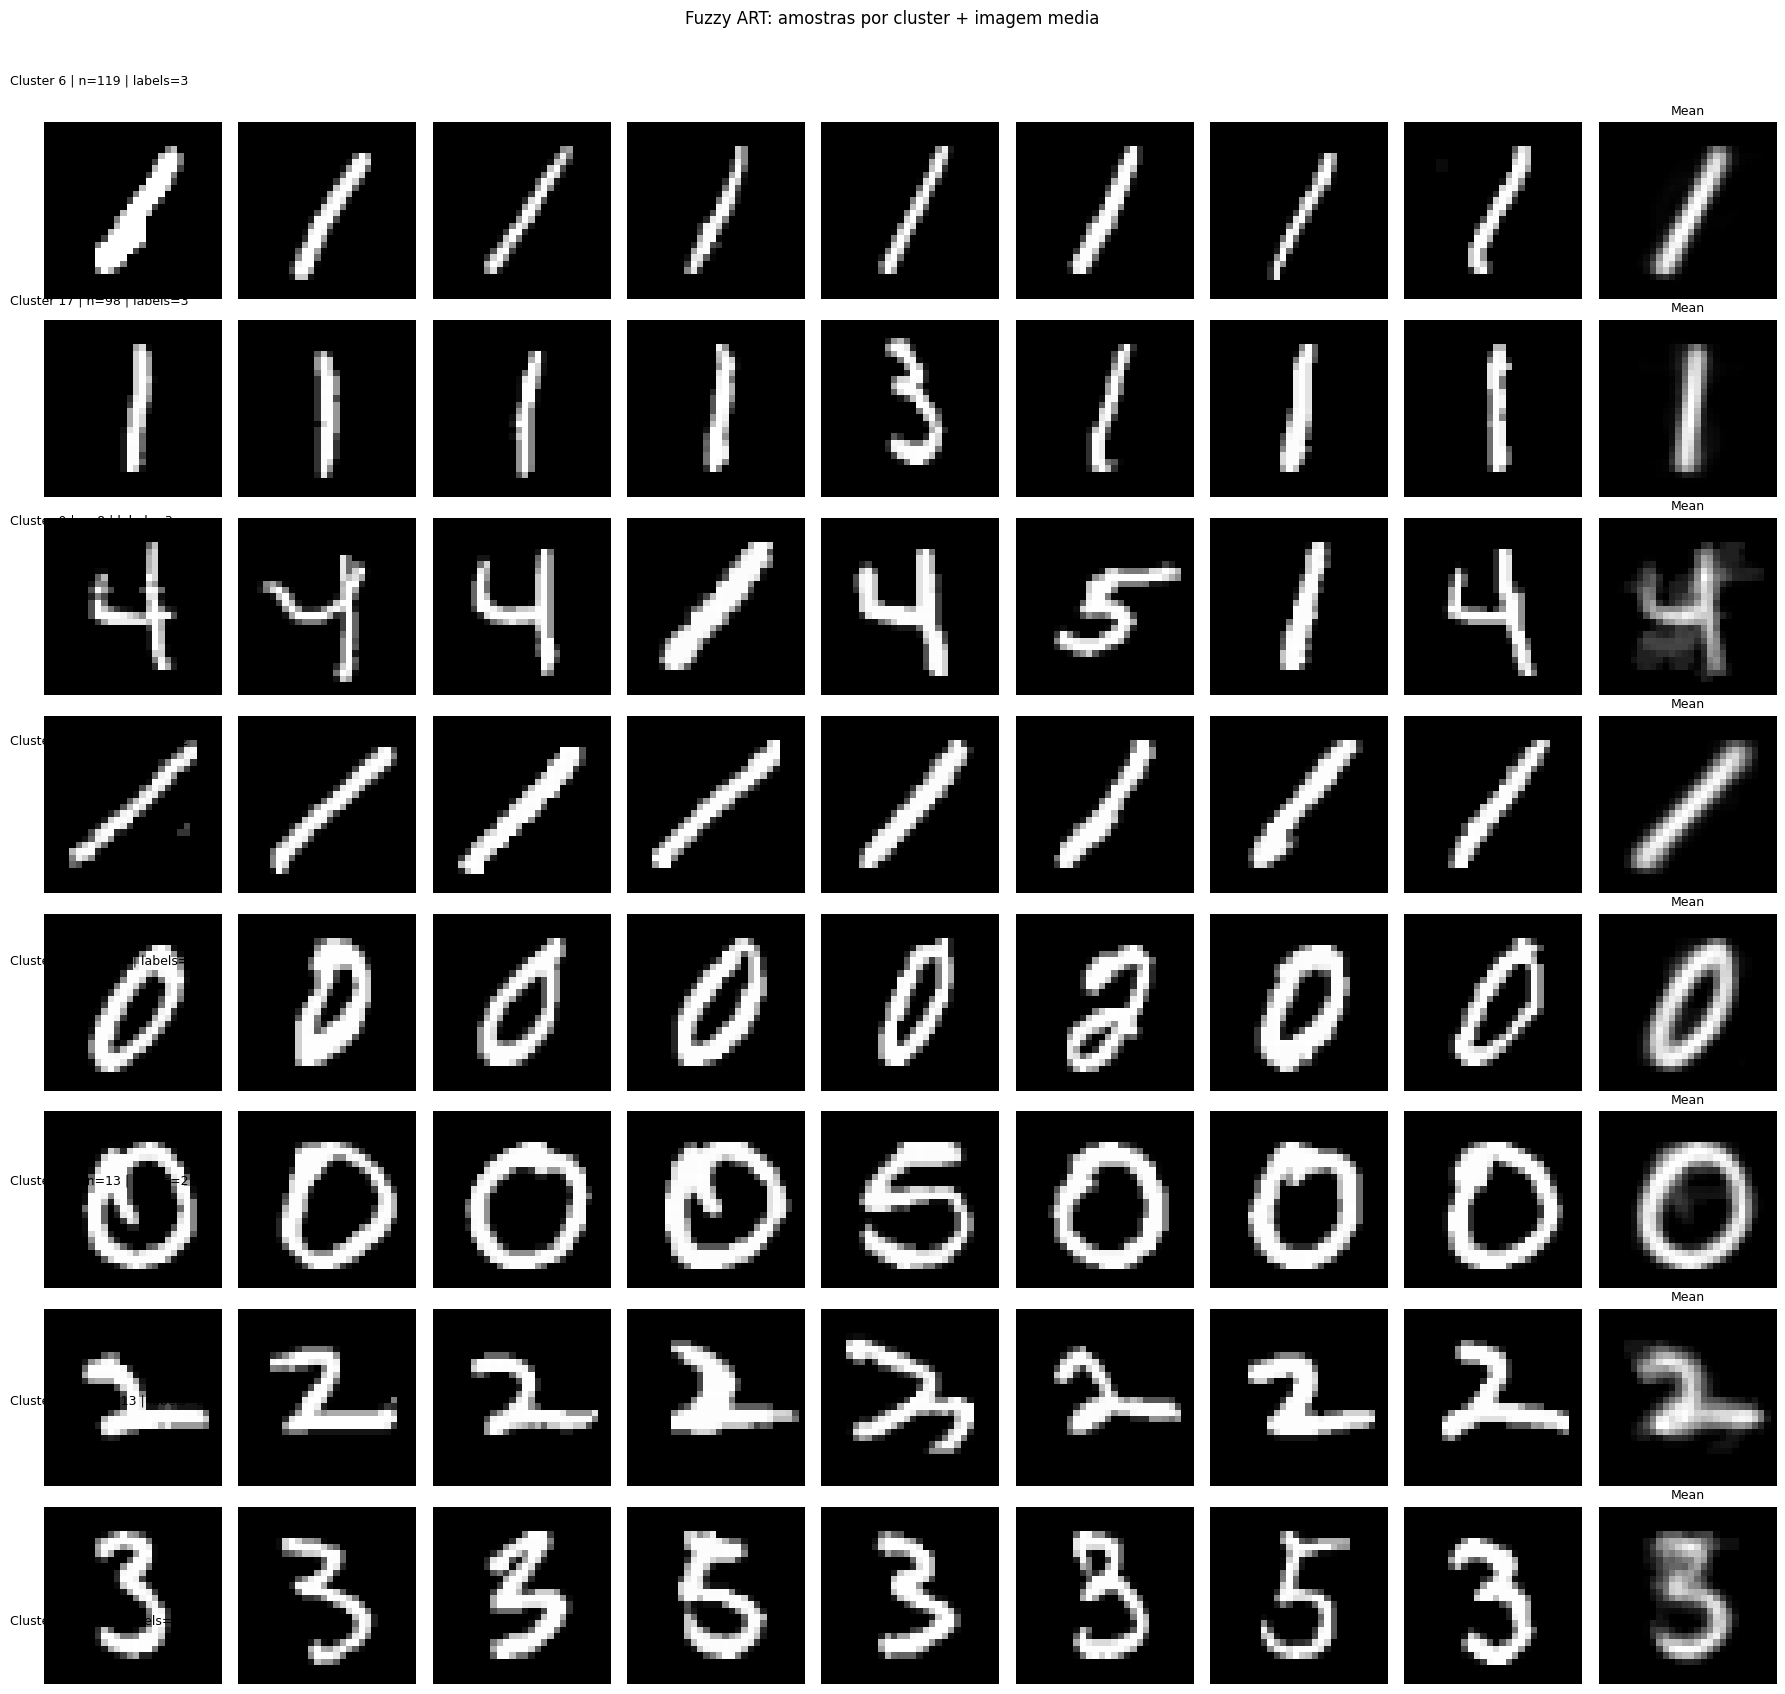

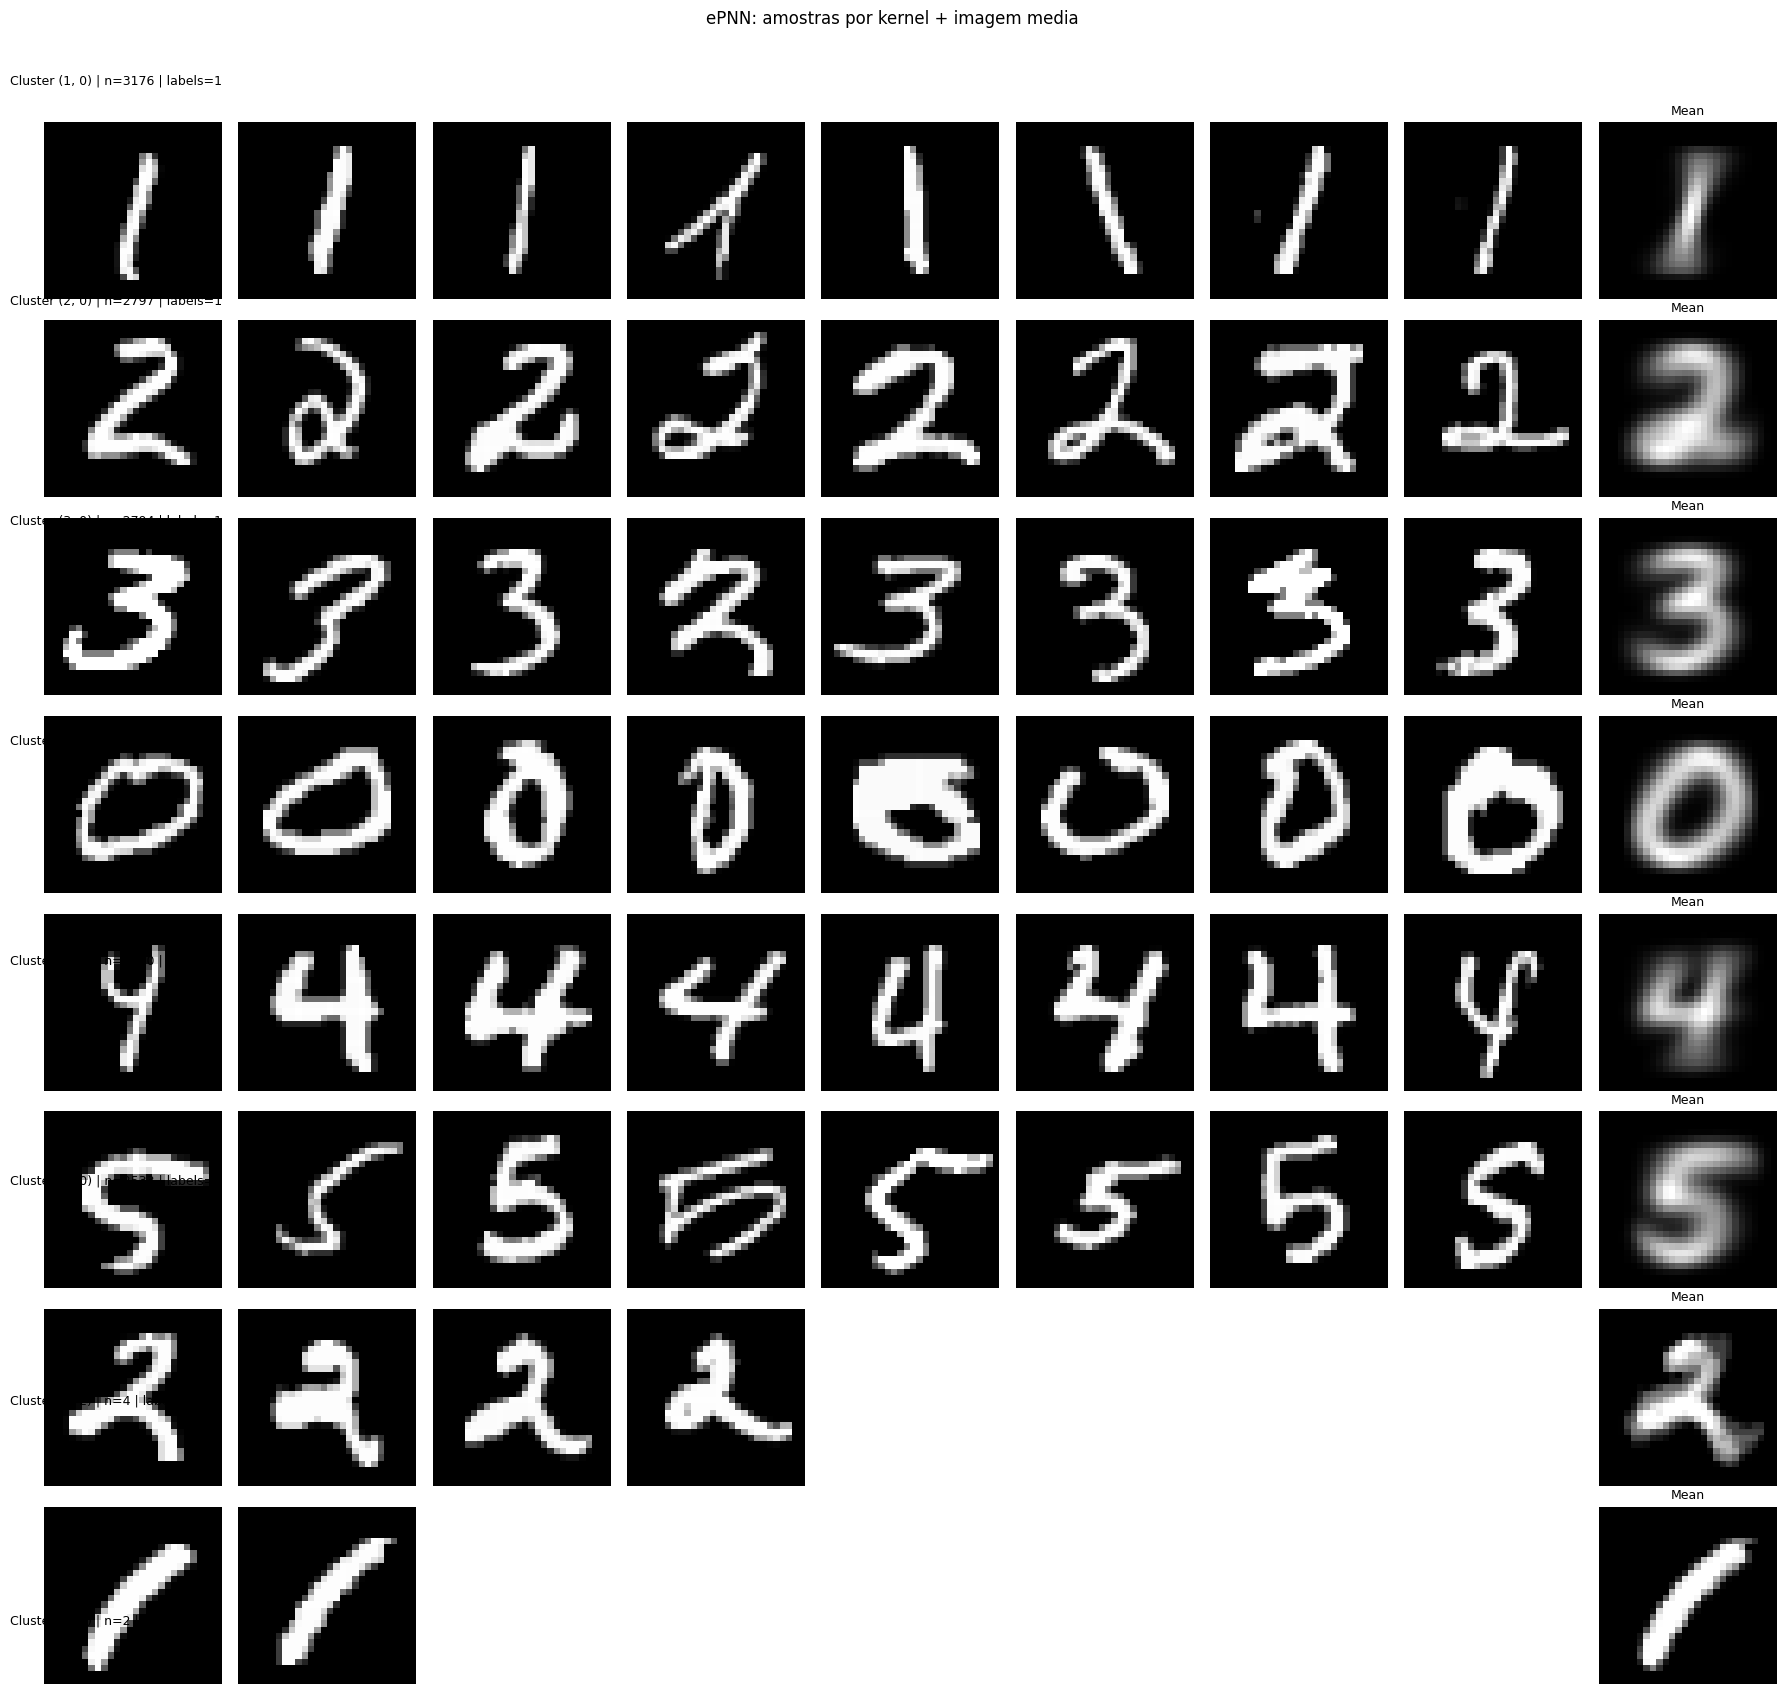

In [24]:
def plot_clusters_with_mean(images, cluster_ids, title, labels=None, max_clusters=8, samples_per_cluster=8):
    # Group indices by cluster id
    groups = {}
    label_array = None if labels is None else np.asarray(labels)
    for i, cid in enumerate(cluster_ids):
        if cid is None:
            continue
        if isinstance(cid, np.ndarray):
            cid = tuple(cid.tolist())
        elif isinstance(cid, list):
            cid = tuple(cid)
        groups.setdefault(cid, []).append(i)
    if not groups:
        print(f"No clusters found for {title}.")
        return
    # Sort clusters by label diversity first, then by size
    scored_clusters = []
    for cid, idxs in groups.items():
        idxs = np.array(idxs)
        if label_array is None:
            diversity = 0
        else:
            diversity = len(np.unique(label_array[idxs]))
        scored_clusters.append((cid, idxs, diversity, len(idxs)))
    scored_clusters.sort(key=lambda item: (-item[2], -item[3]))
    scored_clusters = scored_clusters[:max_clusters]
    cols = samples_per_cluster + 1  # last column is the mean image
    rows = len(scored_clusters)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.0, rows * 2.2))
    if rows == 1:
        axes = np.array([axes])
    for row_idx, (cid, idxs, diversity, cluster_size) in enumerate(scored_clusters):
        n_show = min(samples_per_cluster, len(idxs))
        show_idx = np.random.choice(idxs, size=n_show, replace=False)
        # Plot sample images
        for col in range(samples_per_cluster):
            ax = axes[row_idx, col]
            ax.axis("off")
            if col < n_show:
                img = images[show_idx[col]].reshape(28, 28)
                ax.imshow(img, cmap="gray")
        # Plot mean image (last column)
        mean_img = images[idxs].mean(axis=0).reshape(28, 28)
        ax_mean = axes[row_idx, -1]
        ax_mean.imshow(mean_img, cmap="gray")
        ax_mean.set_title("Mean", fontsize=9)
        ax_mean.axis("off")
        if label_array is None:
            subtitle = f"Cluster {cid} | n={cluster_size}"
        else:
            subtitle = f"Cluster {cid} | n={cluster_size} | labels={diversity}"
        fig.text(0.01, (rows - row_idx - 0.5) / rows, subtitle, fontsize=9)
    plt.suptitle(title, fontsize=12)
    plt.tight_layout(rect=[0.02, 0.02, 1, 0.95])
    plt.show()

# ---- Fuzzy ART clusters ----
fuzzy_n = len(cluster_assignments)
fuzzy_images = X_train_1st_half[:fuzzy_n]
fuzzy_cluster_ids = cluster_assignments[:fuzzy_n]
plot_clusters_with_mean(
    fuzzy_images,
    fuzzy_cluster_ids,
    labels=y_train_1st_half[:fuzzy_n],
    title="Fuzzy ART: amostras por cluster + imagem media",
    max_clusters=8,
    samples_per_cluster=8,
)

# ---- ePNN kernels (cluster = (class_label, kernel_index)) ----
def assign_epnn_kernels(net, X_epnn, y_labels):
    cluster_ids = []
    for i, x in enumerate(X_epnn):
        label = int(y_labels[i])
        gmm = net.gmms.get(label)
        if gmm is None or not gmm.kernels:
            cluster_ids.append(None)
            continue
        acts = [gmm._activation(x, k) * k.weight for k in gmm.kernels]
        k_idx = int(np.argmax(acts))
        cluster_ids.append((label, k_idx))
    return np.array(cluster_ids, dtype=object)

epnn_n = len(X_train_epnn_1st_half)
epnn_images = X_train_1st_half[:epnn_n]
epnn_cluster_ids = assign_epnn_kernels(net_epnn, X_train_epnn_1st_half, y_train_1st_half[:epnn_n])
plot_clusters_with_mean(
    epnn_images,
    epnn_cluster_ids,
    labels=y_train_1st_half[:epnn_n],
    title="ePNN: amostras por kernel + imagem media",
    max_clusters=8,
    samples_per_cluster=8,
)

In [25]:
# Train ePNN on the training set
train_limit = len(X_train_epnn_2nd_half)
for i in range(train_limit):
    net_epnn.train(X_train_epnn_2nd_half[i], int(y_train_2nd_half[i]))

train_correct = 0
train_total = len(X_train_epnn_2nd_half)
for i in range(train_total):
    pred = net_epnn.predict(X_train_epnn_2nd_half[i])
    if pred == int(y_train_2nd_half[i]):
        train_correct += 1
train_accuracy = train_correct / train_total if train_total else 0.0
print(f"ePNN train accuracy: {train_accuracy * 100:.2f}% ({train_correct}/{train_total})")

ePNN train accuracy: 90.89% (15286/16819)


In [26]:
# Test ePNN on the test set
correct = 0
total = len(X_test_epnn)
for i in range(total):
    pred = net_epnn.predict(X_test_epnn[i])
    if pred == y_test[i]:
        correct += 1

accuracy = correct / total if total else 0.0
print(f"ePNN test accuracy: {accuracy * 100:.2f}% ({correct}/{total})")

ePNN test accuracy: 91.30% (7678/8410)


In [ ]:
# Evaluate cluster counts vs vigilance and show cluster size histograms
vigilance_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
max_clusters = 100000
sample_limit = min(100000, len(X_train_1st_half))
results = {}
weights = []
for v in vigilance_values:
    net_v = FuzzyART(
        num_features=X_train_1st_half.shape[1],
        max_clusters=max_clusters,
        vigilance=v,
        learning_rate=0.5,
        alpha=0.01,
        complement=True,
    )
    weights.append(net_v.get_weights())
    assignments = []
    for i, x in enumerate(X_train_1st_half[:sample_limit]):
        try:
            assignments.append(net_v.train(x))
        except RuntimeError:
            break
    assignments = np.array(assignments, dtype=np.int32)
    cluster_ids = np.unique(assignments)
    counts = np.array([np.sum(assignments == cid) for cid in cluster_ids])
    mean_cluster_size = float(np.mean(counts)) if len(counts) else 0.0
    # Build cluster-to-label mapping from training subset
    y_train_subset = y_train_1st_half[:len(assignments)]
    cluster_label_map = {}
    for cid in cluster_ids:
        idx = np.where(assignments == cid)[0]
        labels, label_counts = np.unique(y_train_subset[idx], return_counts=True)
        cluster_label_map[cid] = labels[np.argmax(label_counts)]
    # Evaluate accuracy on test set
    correct = 0
    total = len(X_test)
    for i, x in enumerate(X_test):
        cid = net_v.predict(x)
        if cid == -1:
            continue
        if cluster_label_map.get(cid, None) == y_test[i]:
            correct += 1
    accuracy = correct / total
    results[v] = {
        "num_clusters": net_v.num_clusters,
        "counts": counts,
        "mean_cluster_size": mean_cluster_size,
        "accuracy": accuracy,
    }

print("Accuracy and mean samples/cluster per vigilance:")
for v in vigilance_values:
    print(
        f"v={v:.2f} | clusters={results[v]['num_clusters']} | "
        f"mean_samples={results[v]['mean_cluster_size']:.2f} | "
        f"accuracy={results[v]['accuracy'] * 100:.2f}%"
    )

# Line plot: vigilance vs number of clusters (log Y)
plt.figure(figsize=(7, 4))
plt.plot(list(results.keys()), [results[v]["num_clusters"] for v in results], marker="o")
plt.xlabel("Vigilance")
plt.ylabel("Number of clusters (log scale)")
plt.yscale("log")
plt.title("ART clusters vs vigilance")
plt.grid(True, which="both", alpha=0.3)
plt.show()

# Line plot: vigilance vs mean samples per cluster (log Y)
plt.figure(figsize=(7, 4))
plt.plot(list(results.keys()), [results[v]["mean_cluster_size"] for v in results], marker="o")
plt.xlabel("Vigilance")
plt.ylabel("Mean samples per cluster (log scale)")
plt.yscale("log")
plt.title("Mean cluster size vs vigilance")
plt.grid(True, which="both", alpha=0.3)
plt.show()

# Print exact cluster-size counts per vigilance
for v in vigilance_values:
    counts = results[v]["counts"].astype(int)
    size_counts = np.bincount(counts)
    size_counts = size_counts[1:]  # drop size 0
    sizes = np.arange(1, len(size_counts) + 1)
    print(f"\nVigilance={v:.2f} | cluster-size counts:")
    for size, count in zip(sizes, size_counts):
        if count > 0:
            print(f"  size={size:3d} -> clusters={count}")

# Bar charts: exact count of clusters per sample size (log Y)
cols = 2
rows = int(np.ceil(len(vigilance_values) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = np.array(axes).reshape(-1)
for ax, v in zip(axes, vigilance_values):
    counts = results[v]["counts"].astype(int)
    size_counts = np.bincount(counts)
    size_counts = size_counts[1:]  # drop size 0
    sizes = np.arange(1, len(size_counts) + 1)
    ax.bar(sizes, size_counts, width=0.9, color="#4C78A8", edgecolor="white")
    ax.set_yscale("log")
    ax.set_title(
        f"Vigilance={v} | clusters={results[v]['num_clusters']} | mean={results[v]['mean_cluster_size']:.2f}"
    )
    ax.set_xlabel("Samples per cluster")
    ax.set_ylabel("Count of clusters (log scale)")
    ax.grid(True, axis="y", which="both", alpha=0.2)
    if len(sizes) <= 25:
        ax.set_xticks(sizes)

for ax in axes[len(vigilance_values):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Line plot: number of clusters vs accuracy
plt.figure(figsize=(7, 4))
num_clusters_list = [results[v]["num_clusters"] for v in vigilance_values]
accuracy_list = [results[v]["accuracy"] for v in vigilance_values]

plt.plot(num_clusters_list, accuracy_list, marker="o", color="#E45756")
for v, nc, acc in zip(vigilance_values, num_clusters_list, accuracy_list):
    plt.annotate(f"v={v:.1f}", (nc, acc), textcoords="offset points", xytext=(5, 5), fontsize=8)

plt.xlabel("Number of clusters (log scale)")
plt.ylabel("Accuracy")
plt.xscale("log")
plt.title("Accuracy vs number of clusters")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

Accuracy and mean samples/cluster per vigilance:
v=0.90 | clusters=14072 | mean_samples=1.20 | accuracy=97.67%
v=0.93 | clusters=13955 | mean_samples=1.21 | accuracy=97.13%
v=0.95 | clusters=15163 | mean_samples=1.11 | accuracy=97.21%
v=0.97 | clusters=16230 | mean_samples=1.04 | accuracy=97.59%
v=0.99 | clusters=16710 | mean_samples=1.01 | accuracy=97.82%


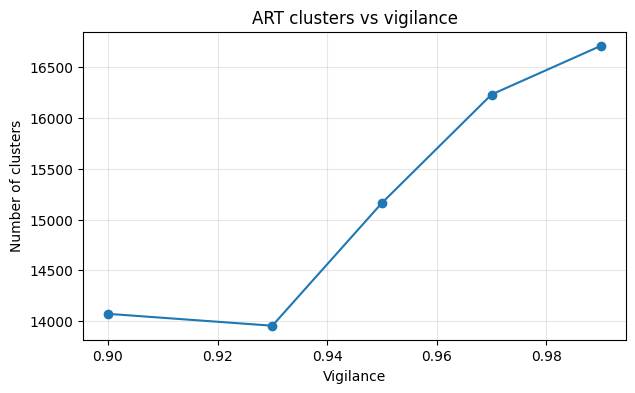

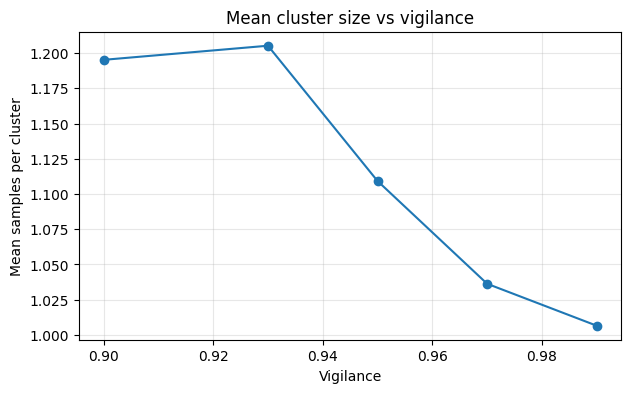


Vigilance=0.90 | cluster-size counts:
  size=  1 -> clusters=12879
  size=  2 -> clusters=539
  size=  3 -> clusters=295
  size=  4 -> clusters=191
  size=  5 -> clusters=94
  size=  6 -> clusters=44
  size=  7 -> clusters=11
  size=  8 -> clusters=6
  size=  9 -> clusters=2
  size= 10 -> clusters=1
  size= 13 -> clusters=1
  size= 15 -> clusters=1
  size= 17 -> clusters=1
  size= 18 -> clusters=1
  size= 26 -> clusters=1
  size= 30 -> clusters=1
  size= 33 -> clusters=1
  size= 34 -> clusters=1
  size= 35 -> clusters=1
  size=105 -> clusters=1

Vigilance=0.93 | cluster-size counts:
  size=  1 -> clusters=12144
  size=  2 -> clusters=1237
  size=  3 -> clusters=429
  size=  4 -> clusters=110
  size=  5 -> clusters=12
  size=  6 -> clusters=3
  size=  7 -> clusters=2
  size=  9 -> clusters=2
  size= 10 -> clusters=2
  size= 12 -> clusters=1
  size= 14 -> clusters=2
  size= 15 -> clusters=2
  size= 17 -> clusters=1
  size= 18 -> clusters=2
  size= 19 -> clusters=1
  size= 23 -> clusters

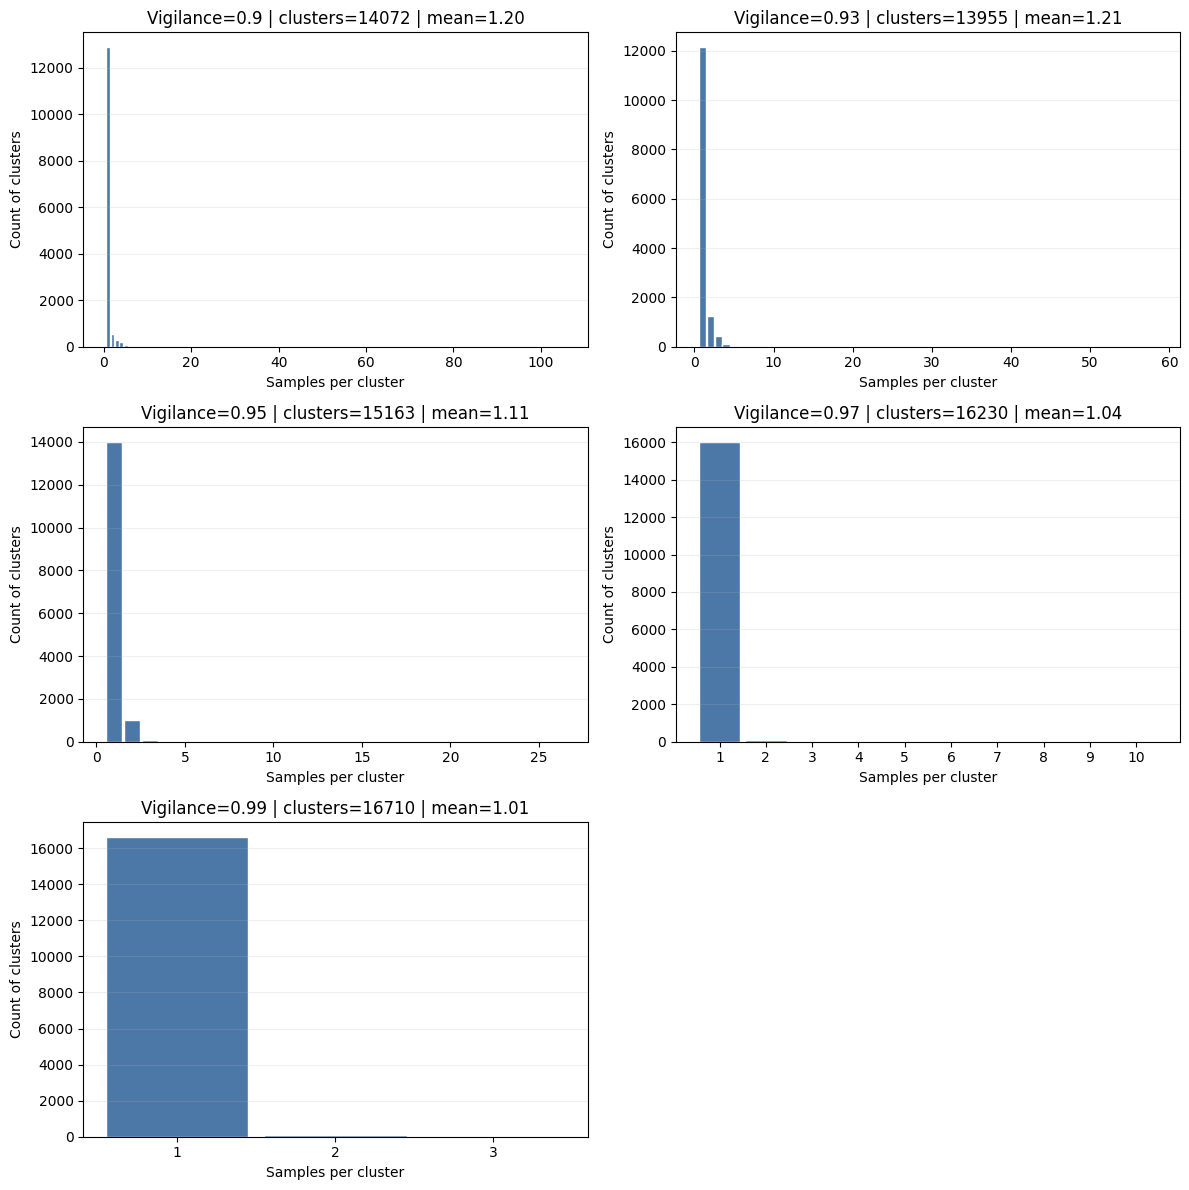

In [ ]:
# Evaluate cluster counts vs vigilance and show cluster size histograms
vigilance_values = [0.9, 0.93, 0.95, 0.97, 0.99]
max_clusters = 100000
sample_limit = min(100000, len(X_train_1st_half))
results = {}
weights = []
for v in vigilance_values:
    net_v = FuzzyART(
        num_features=X_train_1st_half.shape[1],
        max_clusters=max_clusters,
        vigilance=v,
        learning_rate=0.5,
        alpha=0.01,
        complement=True,
    )
    weights.append(net_v.get_weights())
    assignments = []
    for i, x in enumerate(X_train_1st_half[:sample_limit]):
        try:
            assignments.append(net_v.train(x))
        except RuntimeError:
            break
    assignments = np.array(assignments, dtype=np.int32)
    cluster_ids = np.unique(assignments)
    counts = np.array([np.sum(assignments == cid) for cid in cluster_ids])
    mean_cluster_size = float(np.mean(counts)) if len(counts) else 0.0
    # Build cluster-to-label mapping from training subset
    y_train_subset = y_train_1st_half[:len(assignments)]
    cluster_label_map = {}
    for cid in cluster_ids:
        idx = np.where(assignments == cid)[0]
        labels, label_counts = np.unique(y_train_subset[idx], return_counts=True)
        cluster_label_map[cid] = labels[np.argmax(label_counts)]
    # Evaluate accuracy on test set
    correct = 0
    total = len(X_test)
    for i, x in enumerate(X_test):
        cid = net_v.predict(x)
        if cid == -1:
            continue
        if cluster_label_map.get(cid, None) == y_test[i]:
            correct += 1
    accuracy = correct / total
    results[v] = {
        "num_clusters": net_v.num_clusters,
        "counts": counts,
        "mean_cluster_size": mean_cluster_size,
        "accuracy": accuracy,
    }

print("Accuracy and mean samples/cluster per vigilance:")
for v in vigilance_values:
    print(
        f"v={v:.2f} | clusters={results[v]['num_clusters']} | "
        f"mean_samples={results[v]['mean_cluster_size']:.2f} | "
        f"accuracy={results[v]['accuracy'] * 100:.2f}%"
    )

# Line plot: vigilance vs number of clusters (log Y)
plt.figure(figsize=(7, 4))
plt.plot(list(results.keys()), [results[v]["num_clusters"] for v in results], marker="o")
plt.xlabel("Vigilance")
plt.ylabel("Number of clusters (log scale)")
plt.yscale("log")
plt.title("ART clusters vs vigilance")
plt.grid(True, which="both", alpha=0.3)
plt.show()

# Line plot: vigilance vs mean samples per cluster (log Y)
plt.figure(figsize=(7, 4))
plt.plot(list(results.keys()), [results[v]["mean_cluster_size"] for v in results], marker="o")
plt.xlabel("Vigilance")
plt.ylabel("Mean samples per cluster (log scale)")
plt.yscale("log")
plt.title("Mean cluster size vs vigilance")
plt.grid(True, which="both", alpha=0.3)
plt.show()

# Print exact cluster-size counts per vigilance
for v in vigilance_values:
    counts = results[v]["counts"].astype(int)
    size_counts = np.bincount(counts)
    size_counts = size_counts[1:]  # drop size 0
    sizes = np.arange(1, len(size_counts) + 1)
    print(f"\nVigilance={v:.2f} | cluster-size counts:")
    for size, count in zip(sizes, size_counts):
        if count > 0:
            print(f"  size={size:3d} -> clusters={count}")

# Bar charts: exact count of clusters per sample size (log Y)
cols = 2
rows = int(np.ceil(len(vigilance_values) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = np.array(axes).reshape(-1)
for ax, v in zip(axes, vigilance_values):
    counts = results[v]["counts"].astype(int)
    size_counts = np.bincount(counts)
    size_counts = size_counts[1:]  # drop size 0
    sizes = np.arange(1, len(size_counts) + 1)
    ax.bar(sizes, size_counts, width=0.9, color="#4C78A8", edgecolor="white")
    ax.set_yscale("log")
    ax.set_title(
        f"Vigilance={v} | clusters={results[v]['num_clusters']} | mean={results[v]['mean_cluster_size']:.2f}"
    )
    ax.set_xlabel("Samples per cluster")
    ax.set_ylabel("Count of clusters (log scale)")
    ax.grid(True, axis="y", which="both", alpha=0.2)
    if len(sizes) <= 25:
        ax.set_xticks(sizes)

for ax in axes[len(vigilance_values):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Line plot: number of clusters vs accuracy
plt.figure(figsize=(7, 4))
num_clusters_list = [results[v]["num_clusters"] for v in vigilance_values]
accuracy_list = [results[v]["accuracy"] for v in vigilance_values]

plt.plot(num_clusters_list, accuracy_list, marker="o", color="#E45756")
for v, nc, acc in zip(vigilance_values, num_clusters_list, accuracy_list):
    plt.annotate(f"v={v:.1f}", (nc, acc), textcoords="offset points", xytext=(5, 5), fontsize=8)

plt.xlabel("Number of clusters (log scale)")
plt.ylabel("Accuracy")
plt.xscale("log")
plt.title("Accuracy vs number of clusters")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# Results

- ### 0's & 7's
    - *vigilance parameter = 0.3*
        
            Trained samples: 11356
            Active clusters: 8207
            Clusters purity (%) = 99.9%

            Correct predictions: 2834 out of 2840
            Accuracy: 99.79%

    - *vigilance parameter = 0.5*
        
            Trained samples: 11356
            Active clusters: 9249
            Clusters purity (%) = 100%

            Correct predictions: 2830 out of 2840
            Accuracy: 99.65%

    - *vigilance parameter = 0.8*

            Trained samples: 11356
            Active clusters: 10827
            Clusters purity (%) = 100%

            Correct predictions: 2823 out of 2840
            Accuracy: 99.40%

- ### All numbers dataset
    - *vigilance parameter = 0.3*
        
            Trained samples: 56000
            Active clusters: 42866
            Clusters purity (%) = 98.3%

            Correct predictions: 8590 out of 10000
            Accuracy: 85.90%




